In [2]:
# Libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_percentage_error, r2_score
import plotly.express as px
import matplotlib.pyplot as plt

# Reading the dataset
df = pd.read_csv("/content/housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [3]:
# Map with latitude and longitude information from the California Housing dataset
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    color="median_house_value",
    hover_data=[
        "median_house_value",
        "median_income",
        "population"
    ],
    zoom=5
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [4]:
# Defining input and output variables and applying normalization
X = df[["longitude","latitude","housing_median_age",
        "total_rooms","population","households",
        "median_income"]]

y = df["median_house_value"]

# Normalizing input and output variables
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [5]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Training the MLP model
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, n_iter_no_change=300, verbose=True, random_state=42)
mlp.fit(X_train, y_train.ravel())

Iteration 1, loss = 0.27515219
Iteration 2, loss = 0.17793514
Iteration 3, loss = 0.15574273
Iteration 4, loss = 0.14671296
Iteration 5, loss = 0.14100748
Iteration 6, loss = 0.13563060
Iteration 7, loss = 0.13148087
Iteration 8, loss = 0.12926697
Iteration 9, loss = 0.12632577
Iteration 10, loss = 0.12521687
Iteration 11, loss = 0.12142991
Iteration 12, loss = 0.12101339
Iteration 13, loss = 0.11862417
Iteration 14, loss = 0.11794958
Iteration 15, loss = 0.11619790
Iteration 16, loss = 0.11473042
Iteration 17, loss = 0.11400182
Iteration 18, loss = 0.11275503
Iteration 19, loss = 0.11204136
Iteration 20, loss = 0.11154428
Iteration 21, loss = 0.11050815
Iteration 22, loss = 0.11040387
Iteration 23, loss = 0.10999455
Iteration 24, loss = 0.10863822
Iteration 25, loss = 0.10847420
Iteration 26, loss = 0.10798619
Iteration 27, loss = 0.10713029
Iteration 28, loss = 0.10654170
Iteration 29, loss = 0.10605026
Iteration 30, loss = 0.10545410
Iteration 31, loss = 0.10514082
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.



MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=300, n_iter_no_change=300,
             random_state=42, verbose=True)

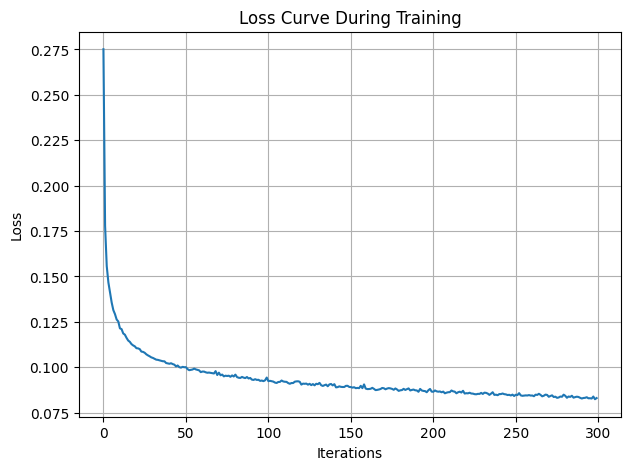

In [7]:
# Plotting the loss curve during training
plt.figure(figsize=(7, 5))
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve During Training")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [8]:
# Predictions for the training data
y_train_pred_scaled = mlp.predict(X_train)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled.reshape(-1, 1))
y_train_original = scaler_y.inverse_transform(y_train)

# Predictions for the testing data
y_test_pred_scaled = mlp.predict(X_test)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1))
y_test_original = scaler_y.inverse_transform(y_test)

# Training results
print("Results - Training")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(y_train_original, y_train_pred) * 100))
print("R2: {:.2f}".format(r2_score(y_train_original, y_train_pred)))

# Testing results
print("\nResults - Testing")
print("MAPE: {:.2f}%".format(mean_absolute_percentage_error(y_test_original, y_test_pred) * 100))
print("R2: {:.2f}".format(r2_score(y_test_original, y_test_pred)))

Results - Training
MAPE: 18.28%
R2: 0.84

Results - Testing
MAPE: 20.27%
R2: 0.79


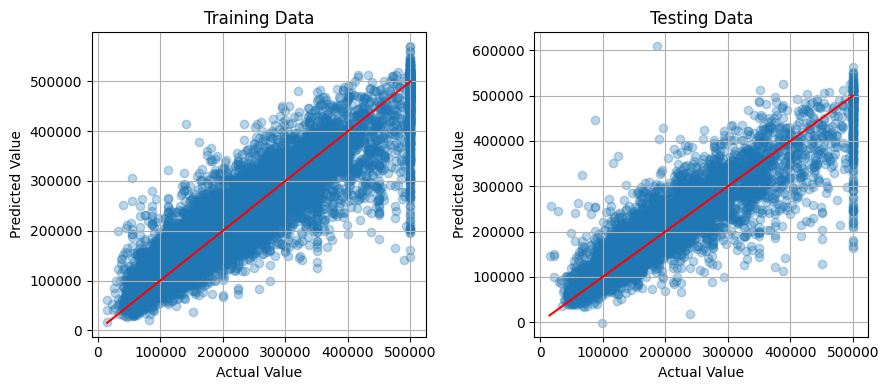

In [11]:
plt.figure(figsize=(9, 4))

# Training Plot
plt.subplot(1, 2, 1)

plt.scatter(y_train_original, y_train_pred, alpha=0.3)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Training Data")

plt.plot(
    [y_train_original.min(), y_train_original.max()],
    [y_train_original.min(), y_train_original.max()],
    color="red"
)

plt.grid(True)

# Testing Plot
plt.subplot(1, 2, 2)

plt.scatter(y_test_original, y_test_pred, alpha=0.3)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Testing Data")

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    color="red"
)

plt.grid(True)

# Ajuste automático de layout
plt.tight_layout()

plt.show()